
FIRST 5 ROWS
   Employee_ID               Name  Gender Department  Age  Salary  \
0            1        Sheri White    Male  Marketing   30  108267   
1            2  Margaret Buchanan  Female      Sales   47   30238   
2            3  Jamie Mccarty DDS    Male         IT   41   55464   
3            4         Tyler Ward  Female      Sales   46   57637   
4            5    Jennifer Ortega    Male         IT   25   78706   

   Experience_Years Performance_Rating            City  Work_Hours_Per_Week  
0                 6            Average  Mccormickburgh                   30  
1                32               Poor    Anthonymouth                   49  
2                16            Average  North Michelle                   57  
3                14          Excellent     Ramirezbury                   46  
4                25          Excellent       West John                   45  

DATASET SHAPE
(200, 10)

COLUMN NAMES
Index(['Employee_ID', 'Name', 'Gender', 'Department', 'Age', 'Sa

/tmp/ipykernel_3398/1084023401.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_3398/1084023401.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

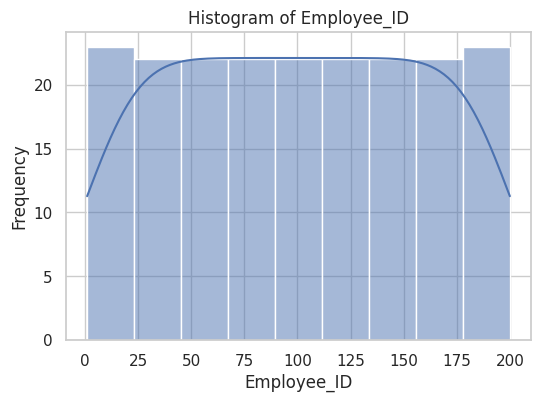

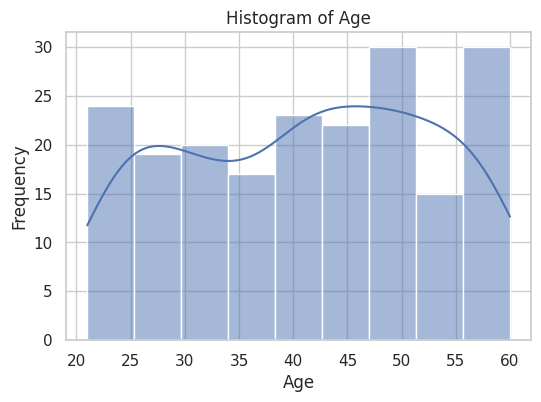

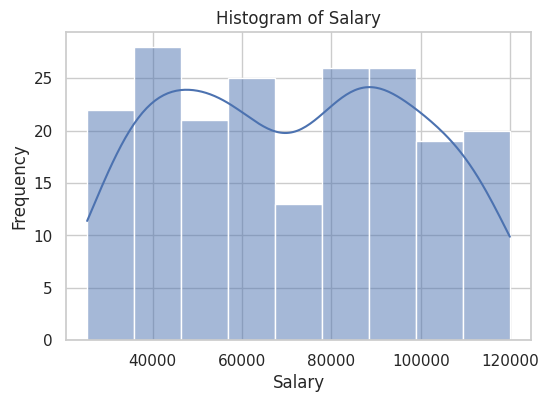

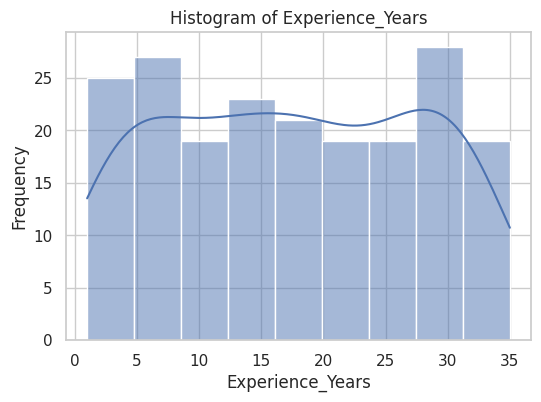

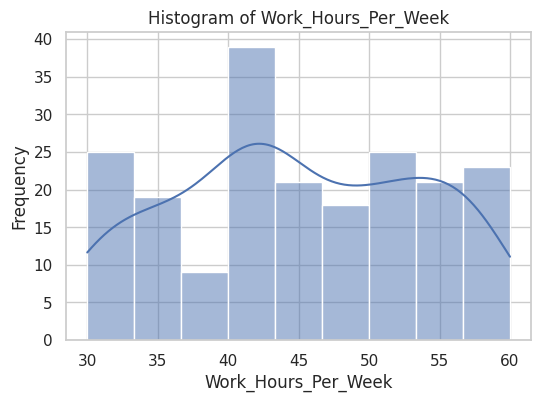

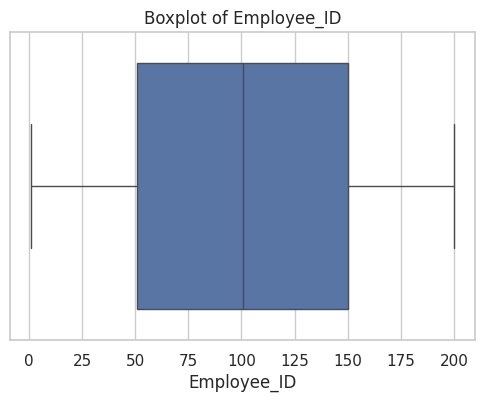

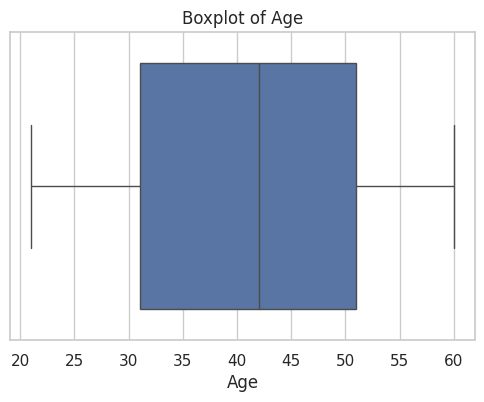

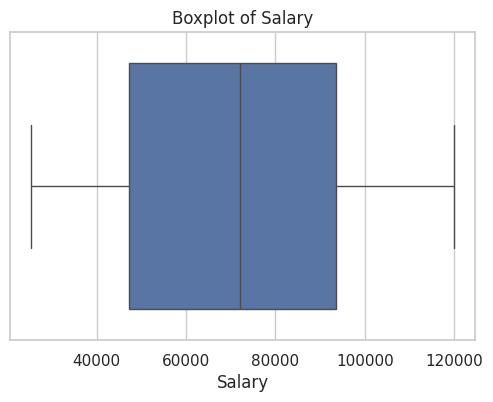

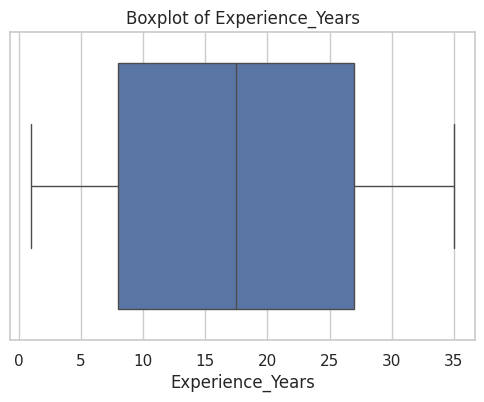

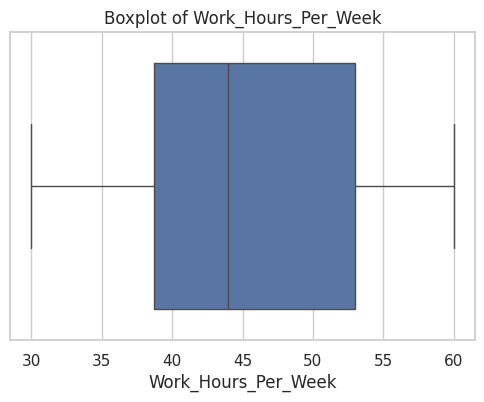

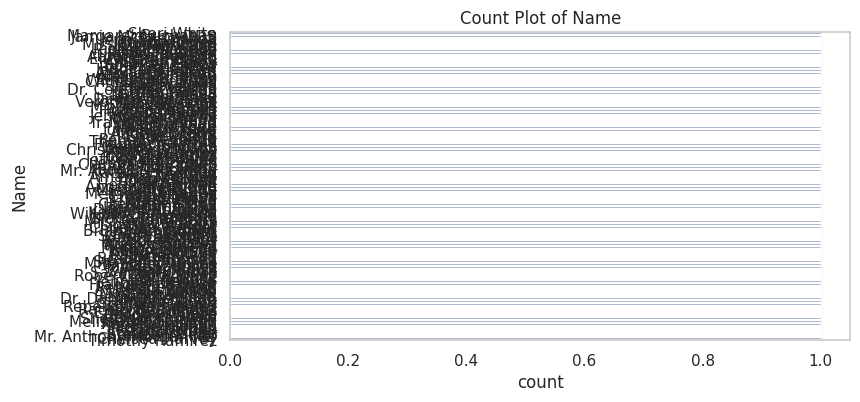

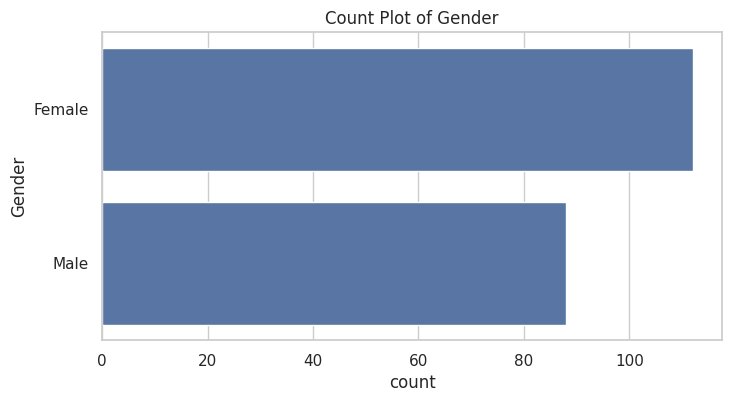

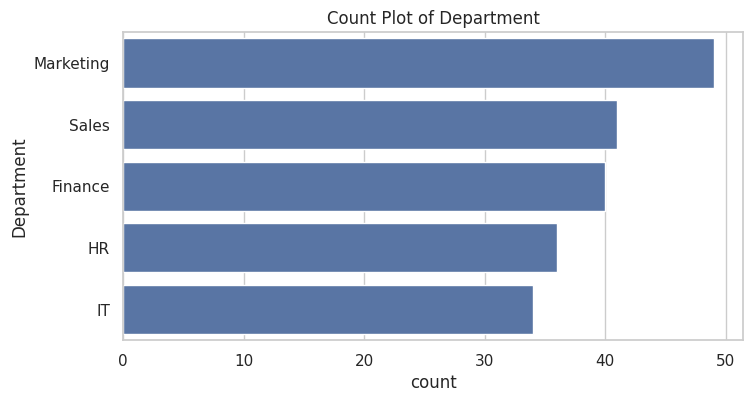

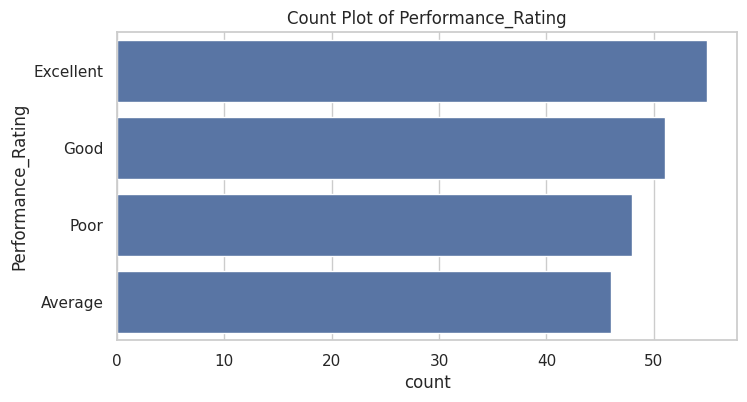

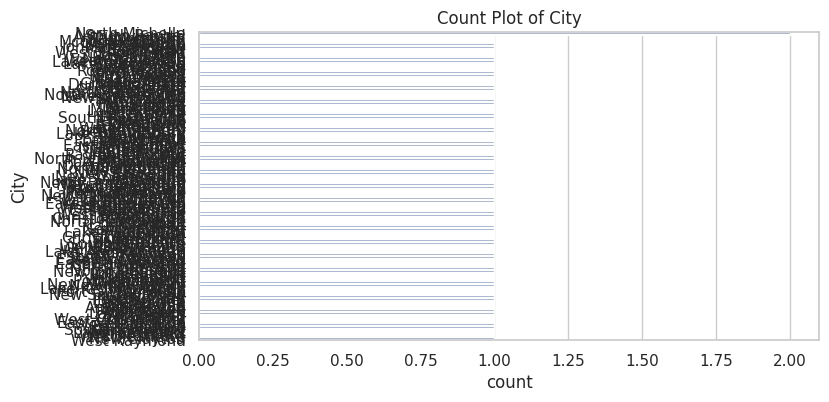

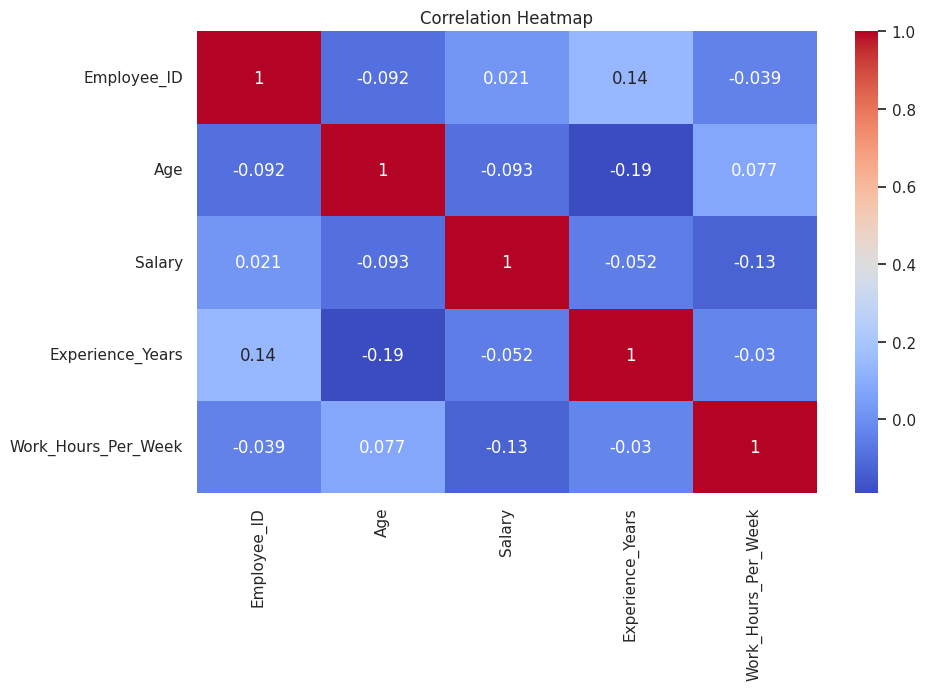

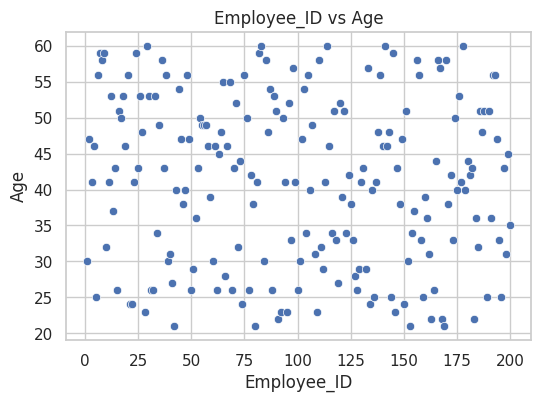


Analysis for Employee_ID
Mean : 100.5
Median : 100.5
Maximum : 200
Minimum : 1
Standard Deviation : 57.879184513951124

Analysis for Age
Mean : 41.14
Median : 42.0
Maximum : 60
Minimum : 21
Standard Deviation : 11.60533580278819

Analysis for Salary
Mean : 71546.625
Median : 72068.0
Maximum : 119896
Minimum : 25376
Standard Deviation : 27179.344710992755

Analysis for Experience_Years
Mean : 17.505
Median : 17.5
Maximum : 35
Minimum : 1
Standard Deviation : 10.155077696161435

Analysis for Work_Hours_Per_Week
Mean : 44.95
Median : 44.0
Maximum : 60
Minimum : 30
Standard Deviation : 8.713617829489198

TOP CORRELATIONS
                     Employee_ID       Age    Salary  Experience_Years  \
Employee_ID             1.000000 -0.091621  0.020814          0.143337   
Age                    -0.091621  1.000000 -0.093396         -0.191156   
Salary                  0.020814 -0.093396  1.000000         -0.051632   
Experience_Years        0.143337 -0.191156 -0.051632          1.000000   
Work

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("exploratory_data_analysis.csv")

print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATASET INFORMATION")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe(include='all'))

print("\nMISSING VALUES")
print(df.isnull().sum())

numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include='object').columns

for col in numeric_columns:
    df[col].fillna(df[col].mean(), inplace=True)

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nDUPLICATE VALUES")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("\nCORRELATION MATRIX")
print(df.corr(numeric_only=True))

sns.set(style="whitegrid")

for col in numeric_columns:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(f"Histogram of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

for col in numeric_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

for col in categorical_columns:

    plt.figure(figsize=(8,4))

    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index
    )

    plt.title(f"Count Plot of {col}")

    plt.show()

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

if len(numeric_columns) >= 2:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=numeric_columns[0],
        y=numeric_columns[1],
        data=df
    )

    plt.title(
        f"{numeric_columns[0]} vs {numeric_columns[1]}"
    )

    plt.show()

for col in numeric_columns:

    print(f"\nAnalysis for {col}")

    print("Mean :", df[col].mean())
    print("Median :", df[col].median())
    print("Maximum :", df[col].max())
    print("Minimum :", df[col].min())
    print("Standard Deviation :", df[col].std())

print("\nTOP CORRELATIONS")

correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

df.to_csv("EDA_Cleaned_Output.csv", index=False)

print("\nEDA PROJECT COMPLETED SUCCESSFULLY")